In [1]:
import mcstasscript as ms
import mcstastox as mx
import scipp as sc
from scipp.typing import VariableLike
import scipp as sc
import matplotlib.pyplot as plt
from scippneutron.conversion.graph.beamline import beamline
import numpy as np

import os
import sys 



module_source = os.path.dirname(os.path.dirname(os.getcwd()))

sys.path.append(module_source)
from trex_reduction_lam_monitor import inelastic
from trex_reduction_lam_monitor import produce_trex_event_object



cspec_source_samp = {'source_name': "ESS_Source", 
                     'sample_name': "Sample"}

let_source_samp = {'source_name': "SourceMantid", 
                     'sample_name': "iso_samp"}

trex_source_samp = {'source_name': "ESS_source", 
                     'sample_name': "Sample"}

In [2]:
exp_folder = "TREX_generated_8"
file_path = os.path.join(module_source, "runs", exp_folder)

with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp(**trex_source_samp)

    
data = ms.load_data(file_path)

for mon in data:
    mon.set_title(mon.name)

lambda_tom = ms.name_search('Cheat_lambda_tof_monitor',data)

event_object = scipp_object
# McStas provides absolute time, not time of flight
event_object['events'].bins.coords["tof"] = event_object['events'].bins.coords["t"] #+ sc.scalar(2.86e-3/2, unit = 's')
event_object

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 28464}),
    positions: Variable({'pixel_id': 30056}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

Skipped plotting Trex_banana_det as it contains event data.


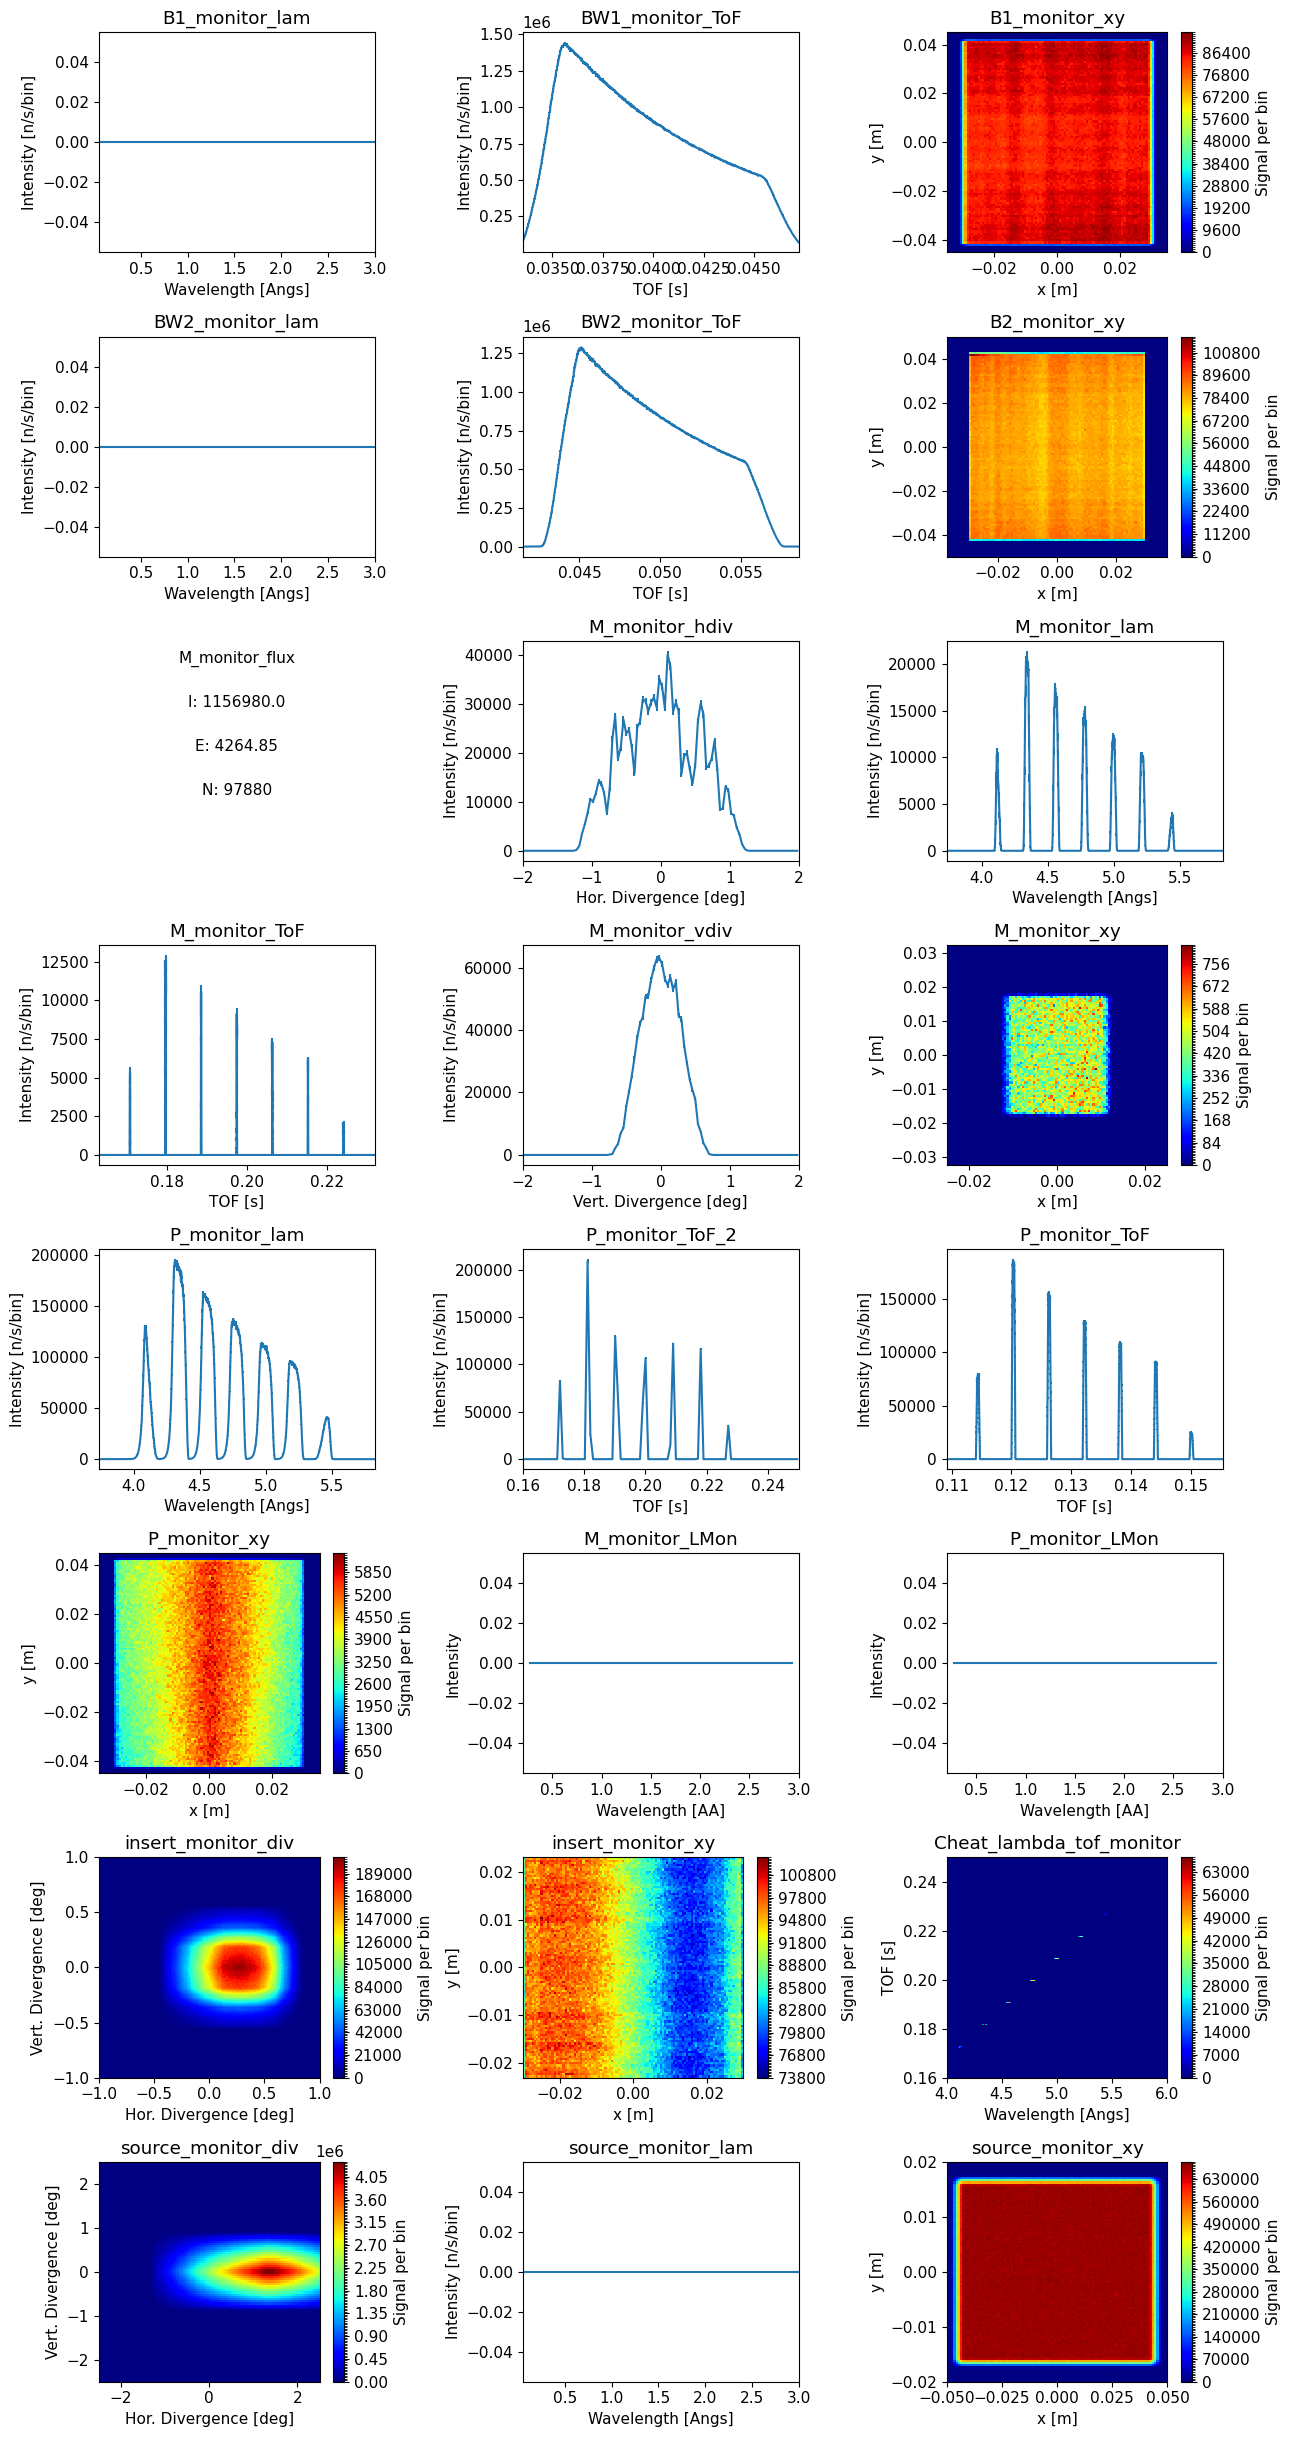

In [3]:
ms.make_sub_plot(data)

In [4]:
lambda_tom = ms.name_search('Cheat_lambda_tof_monitor',data)

event_object['events'] = produce_trex_event_object(event_object['events'], lambda_tom, lambda_tom.Intensity.sum(axis=1).max()*0.1, n_bins=4)
qens_graph = {**beamline(scatter=True), **inelastic}

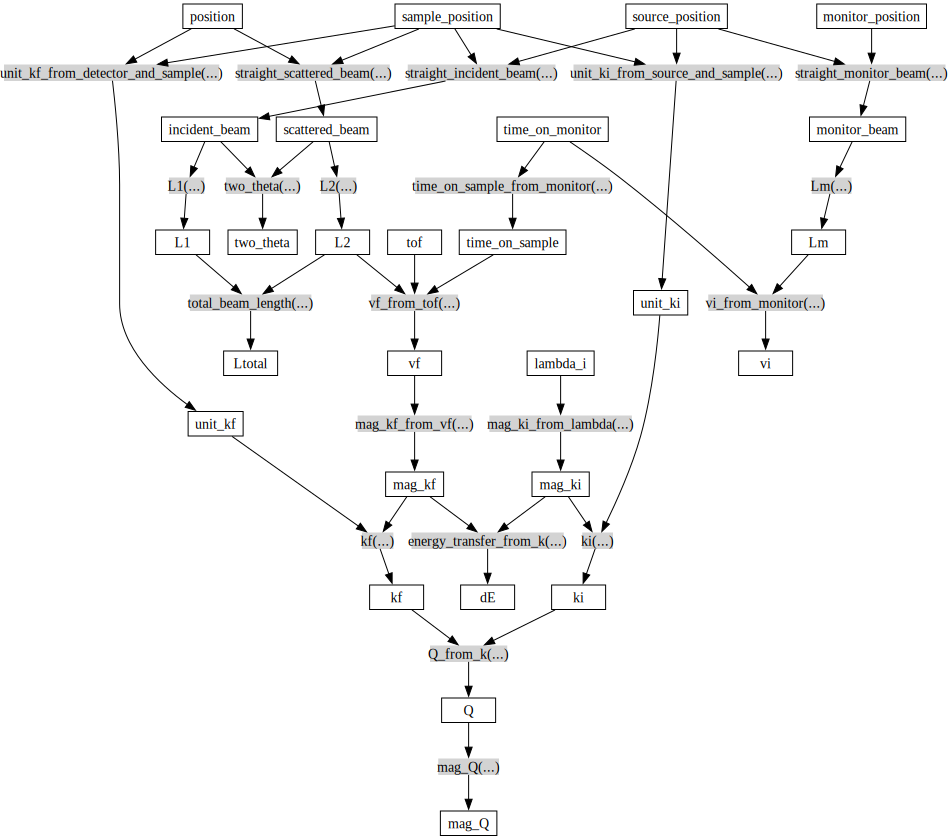

In [5]:
sc.show_graph(qens_graph)


In [6]:
event_object['events'] = event_object['events'].transform_coords("dE", graph=qens_graph)
event_object['events'] = event_object['events'].transform_coords("mag_Q", graph=qens_graph)


# Q and vf range

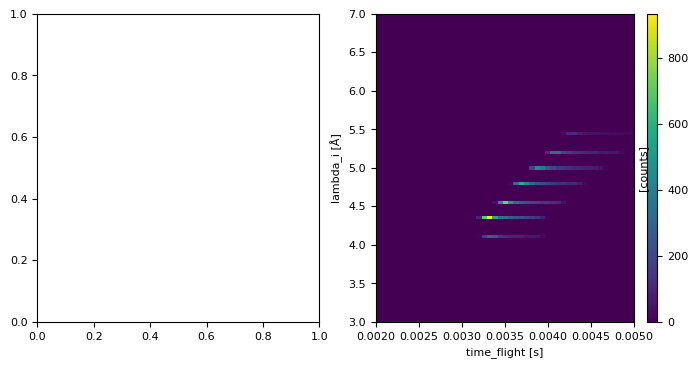

In [21]:
# Apply mask to the binned variable
fig, ax = plt.subplots(1,2,figsize= (8,4))

event_object['events'].bins.coords['time_flight'] = event_object['events'].bins.coords['tof'] - event_object['events'].bins.coords['time_on_monitor']

# vi_range = sc.array(values=np.linspace(500,1000,300),unit = 'm/s', dims=['vi'])
# event_object['events'].bin(vi=vi_range).sum('pixel_id').plot(ax=ax[0], linestyle='-', color='tab:blue')
lam_range = sc.array(values=np.linspace(3,7,100),unit = 'Angstrom', dims=['lambda_i'])
tom_range = sc.array(values=np.linspace(0.16, 0.24, 50), unit='s', dims=['time_on_monitor'])
tof_range = sc.array(values=np.linspace(0.16, 0.24, 50), unit='s', dims=['tof'])
time_flight_range = sc.array(values=np.linspace(0.002, 0.005, 50), unit='s', dims=['time_flight'])
event_object['events'].bin(lambda_i=lam_range, time_flight = time_flight_range).sum('pixel_id').plot(ax=ax[1])
plt.show()

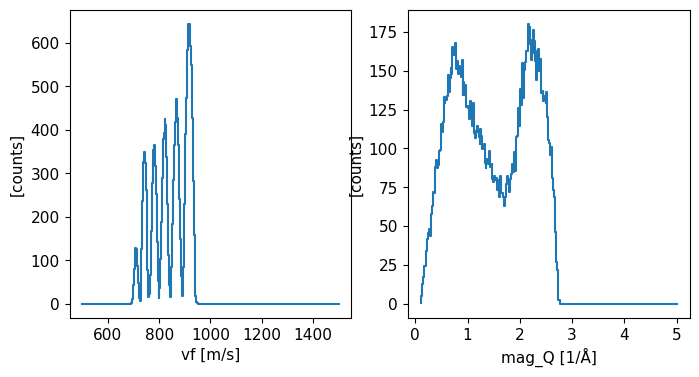

In [10]:
fig, ax = plt.subplots(1,2, figsize= (8,4))


# Apply mask to the binned variable
vf_range = sc.array(values=np.linspace(500,1500,300),unit = 'm/s', dims=['vf'])
event_object['events'].bin(vf=vf_range).sum('pixel_id').plot(ax=ax[0], linestyle='-', color='tab:blue')
# ax.set_xlim(0,2000)

# mask = event_object.coords['vf'] < sc.scalar(5000, unit=event_object.coords['vf'].unit)
Q_range = sc.array(values=np.linspace(0.1,5,300),unit = '1/Angstrom', dims=['mag_Q'])
event_object['events'].bin(mag_Q=Q_range).sum('pixel_id').plot(ax=ax[1], linestyle='-', color='tab:blue')

plt.show()

# Assigned lambda and time on monitor

In [11]:
sc.constants.h

<scipp.Variable> ()    float64            [J*s]  6.62607e-34

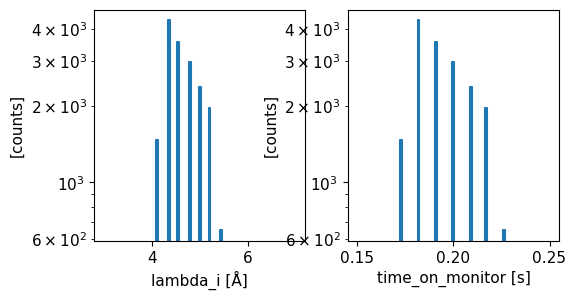

In [12]:
fig,ax = plt.subplots(1,2, figsize = (6,3))

lam_range = sc.array(values=np.linspace(3,7,100),unit = 'Angstrom', dims=['lambda_i'])
event_object['events'].bin(lambda_i = lam_range).sum('pixel_id').plot(ax=ax[0], norm = 'log')

tom_range = sc.array(values=np.linspace(0.15,0.25,100),unit = 's', dims=['time_on_monitor'])
event_object['events'].bin(time_on_monitor = tom_range).sum('pixel_id').plot(ax=ax[1], norm = 'log')

plt.show()

# Checking time on monitor assignement

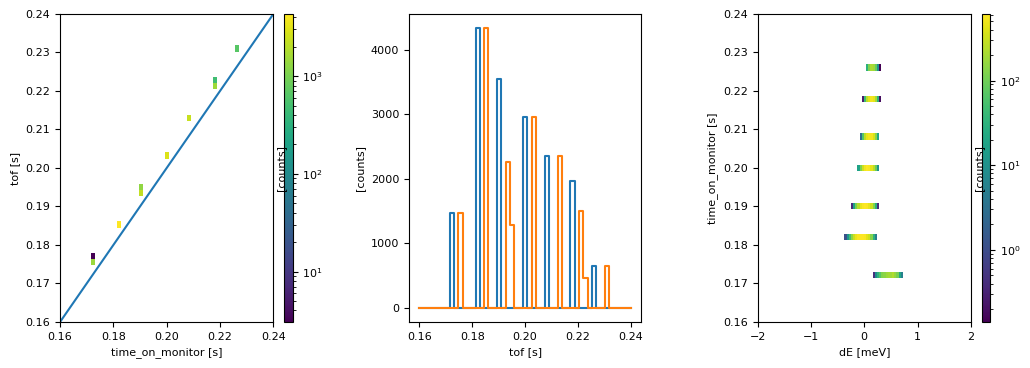

In [19]:

plt.rc('font', size=8)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
tof_range = sc.array(values=np.linspace(0.16, 0.24, 50), unit='s', dims=['tof'])
tom_range = sc.array(values=np.linspace(0.16, 0.24, 50), unit='s', dims=['time_on_monitor'])
lamda_range = sc.array(values=np.linspace(4, 6, 50), unit='Angstrom', dims=['lambda_i'])

event_object['events'].bin(tof=tof_range, time_on_monitor=tom_range).sum('pixel_id').plot(ax=ax[0], norm='log')


# tof_range = sc.array(values=np.linspace(0.16, 0.24, 300), unit='s', dims=['tof'])
# tom_range = sc.array(values=np.linspace(0.16, 0.24, 300), unit='s', dims=['time_on_monitor'])

event_object['events'].bin(time_on_monitor=tom_range).sum('pixel_id').plot(ax=ax[1])
event_object['events'].bin(tof=tof_range).sum('pixel_id').plot(ax=ax[1], color='tab:orange')


dE_range = sc.array(values=np.linspace(-2,2,100),unit = 'meV', dims=['dE'])
# lamda_range = sc.array(values=np.linspace(4,6,100),unit = 'Angstrom', dims=['lambda_i'])
event_object['events'].bin(time_on_monitor = tom_range,dE = dE_range).sum('pixel_id').plot(norm = 'log', ax = ax[2])

fig.subplots_adjust(wspace=0.5)

ax[0].plot(tom_range.values,tof_range.values)


# spectra at 5Ang (3.7mev pulse)

In [14]:
Q_range = sc.array(values=np.linspace(0.3,1.5,100),unit = '1/Angstrom', dims=['mag_Q'])
dE_range = sc.array(values=np.linspace(-2,2,100),unit = 'meV', dims=['dE'])

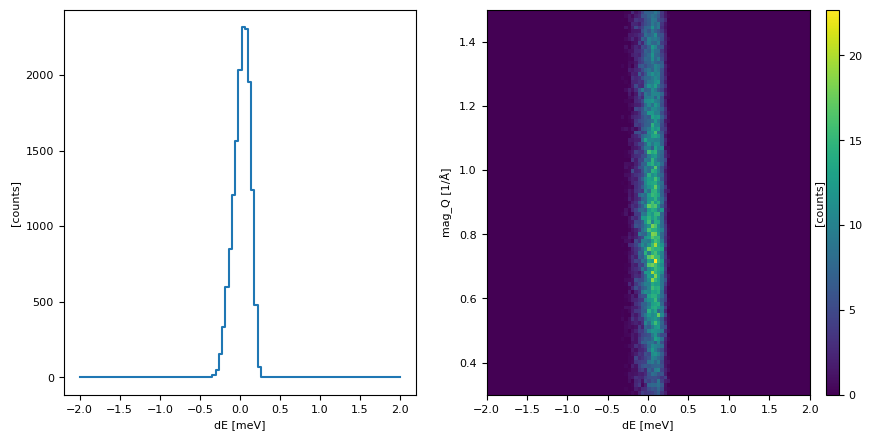

In [15]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

masked = event_object['events'].copy()
target_tom = sc.scalar(0.2, unit='s')
tol = sc.scalar(0.02, unit='s')

mask = abs(masked.bins.coords['time_on_monitor'] - target_tom) > tol
masked.bins.masks['tom'] = mask
masked.hist(dE=dE_range).sum('pixel_id').plot(linestyle='-', color='tab:blue', ax=ax[0])

masked.bin(mag_Q = Q_range, dE=dE_range).sum('pixel_id').plot(ax=ax[1])
plt.show()


# All pulse spectra

In [16]:
import numpy as np

all_values = []

for i in range(1000):
    values = event_object['events'].bins.coords['time_on_monitor'].values[i].values
    all_values.append(values)

# Concatenate all arrays and get unique values
unique_toms = np.unique(np.concatenate(all_values))
unique_toms

array([0.17238551, 0.1816    , 0.1906    , 0.1996    , 0.2086    ,
       0.2176    , 0.2266    ])

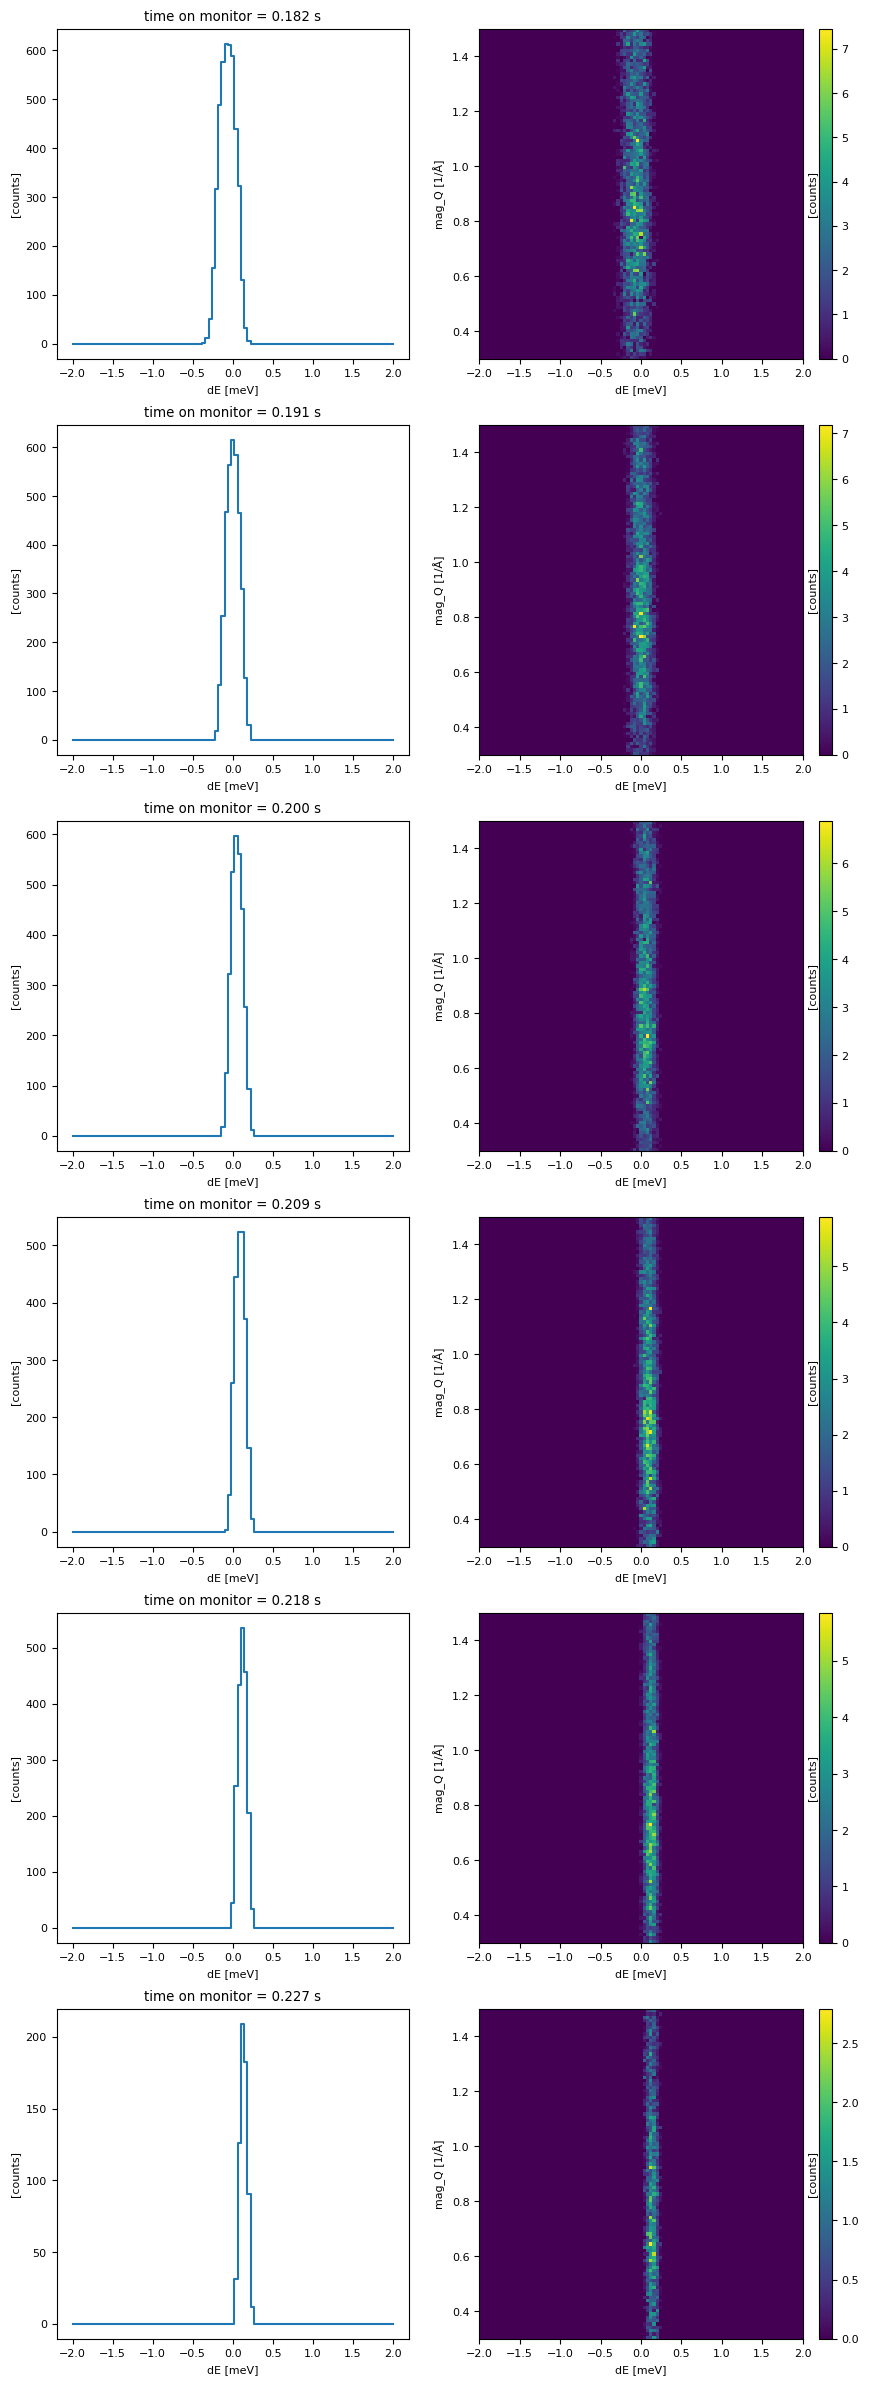

In [17]:
import numpy as np

all_values = []

for i in range(100):
    values = event_object['events'].bins.coords['time_on_monitor'].values[i].values
    all_values.append(values)
unique_toms = np.unique(np.concatenate(all_values))
unique_toms = unique_toms[1:]


fig, ax = plt.subplots(1*len(unique_toms),2,figsize=(10,5*len(unique_toms)))

for i, tom in enumerate(unique_toms):


    mask = masked.bins.coords['time_on_monitor'] != sc.scalar(tom, unit='s')
    masked = event_object['events'].copy()
    masked.bins.masks['tom'] = mask
    masked.hist(dE=dE_range).sum('pixel_id').plot(linestyle='-', color='tab:blue', ax=ax[i, 0])
    masked.bin(mag_Q = Q_range, dE=dE_range).sum('pixel_id').plot(ax=ax[i, 1])
    ax[i, 0].set_title(f"time on monitor = {tom:.3f} s")



plt.show()